In [1]:
RETRAIN_XGB = False


In [2]:
## imports for XGBoost multi-class classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import os

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)

np.random.seed(42)

## loading preprocessed data (from notebook 02) + reconstruction errors (from notebook 03)
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

recon_error_train = np.load('../data/processed/recon_error_train.npy')
recon_error_test  = np.load('../data/processed/recon_error_test.npy')

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"recon_error_train: {recon_error_train.shape}, recon_error_test: {recon_error_test.shape}")

label_map = {0: 'Normal', 1: 'DoS', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
print("\nClass distribution (train):")
for cid, cname in label_map.items():
    print(f"  {cname:8s}: {(y_train == cid).sum()}")

X_train: (125973, 122), X_test: (22251, 122)
recon_error_train: (125973,), recon_error_test: (22251,)

Class distribution (train):
  Normal  : 67343
  DoS     : 45927
  Probe   : 11656
  R2L     : 995
  U2R     : 52


In [3]:
recon_error_content_train = np.load('../data/processed/recon_error_content_train.npy')
recon_error_content_test  = np.load('../data/processed/recon_error_content_test.npy')
recon_error_other_train = np.load('../data/processed/recon_error_other_train.npy')
recon_error_other_test  = np.load('../data/processed/recon_error_other_test.npy')
X_train_hybrid = np.hstack([
    X_train,
    recon_error_content_train.reshape(-1, 1),
    recon_error_other_train.reshape(-1, 1),
])
X_test_hybrid = np.hstack([
    X_test,
    recon_error_content_test.reshape(-1, 1),
    recon_error_other_test.reshape(-1, 1),
])
print(f"Hybrid shape: {X_train_hybrid.shape}")   # (125973, 124)
print(f"Baseline shape: {X_train.shape}")         # (125973, 122)

Hybrid shape: (125973, 124)
Baseline shape: (125973, 122)


In [4]:
score_train = np.load("../data/preprocessed/behavioral_gaussian_score_train.npy")
score_test  = np.load("../data/preprocessed/behavioral_gaussian_score_test.npy")

In [5]:
X_train_125 = np.hstack([X_train_hybrid, score_train.reshape(-1, 1)])
X_test_125  = np.hstack([X_test_hybrid, score_test.reshape(-1, 1)])
assert X_train_125.shape[1] == X_train_hybrid.shape[1] + 1
print("125-feature matrix:", X_train_125.shape, X_test_125.shape)

125-feature matrix: (125973, 125) (22251, 125)


In [20]:
# Custom class weights: amplify R2L and U2R beyond balanced
from collections import Counter

class_counts = Counter(y_train)
n_samples = len(y_train)
n_classes = len(class_counts)

# invert label_map locally so this cell doesn't depend on which
# version of label_map (int->name or name->int) happens to be live
id_to_name = {v: k for k, v in label_map.items()} if isinstance(next(iter(label_map)), str) else label_map

# Start from balanced weights
base_weights = {c: n_samples / (n_classes * count) for c, count in class_counts.items()}

# Amplify R2L (3) and U2R (4) by 3x on top of balanced
custom_weights = base_weights.copy()
custom_weights[3] = base_weights[3] * 4.0  # R2L
custom_weights[4] = base_weights[4] * 4.0  # U2R

print("Custom class weights:")
for c, w in sorted(custom_weights.items()):
    print(f"  {id_to_name[c]:6s} (class {c}): {w:.2f}")

custom_sample_weights = np.array([custom_weights[y] for y in y_train])
FIXED_PARAMS = dict(n_estimators=200, max_depth=8, learning_rate=0.1,   # match your shipped max_depth
                     subsample=0.8, colsample_bytree=0.8, random_state=42,
                     objective="multi:softprob", num_class=5, eval_metric="mlogloss", n_jobs=-1)
# build params dict, then override so we don't pass duplicate kwargs
cost_params = {
    **FIXED_PARAMS,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
}
xgb_cost = XGBClassifier(**cost_params)

xgb_cost.fit(X_train_125, y_train, sample_weight=custom_sample_weights)
y_pred_cost = xgb_cost.predict(X_test_125)

f1_cost = f1_score(y_test, y_pred_cost, average='macro')
print(f"\nCost-Sensitive Model Macro F1: {f1_cost:.4f}\n")
print(classification_report(y_test, y_pred_cost, target_names=list(label_map.values()) if isinstance(next(iter(label_map)), int) else list(label_map.keys())))

cm_cost = confusion_matrix(y_test, y_pred_cost)
print("Confusion Matrix:")
class_names = list(id_to_name.values())
print(pd.DataFrame(cm_cost, index=class_names, columns=class_names))

Custom class weights:
  Normal (class 0): 0.37
  DoS    (class 1): 0.55
  Probe  (class 2): 2.16
  R2L    (class 3): 101.28
  U2R    (class 4): 1938.05

Cost-Sensitive Model Macro F1: 0.6539

              precision    recall  f1-score   support

      Normal       0.75      0.97      0.84      9711
         DoS       0.96      0.89      0.92      7167
       Probe       0.82      0.86      0.84      2421
         R2L       0.98      0.15      0.27      2885
         U2R       0.59      0.30      0.40        67

    accuracy                           0.82     22251
   macro avg       0.82      0.63      0.65     22251
weighted avg       0.85      0.82      0.79     22251

Confusion Matrix:
        Normal   DoS  Probe  R2L  U2R
Normal    9428    71    206    2    4
DoS        563  6360    244    0    0
Probe      167   168   2086    0    0
R2L       2406     1     23  445   10
U2R         41     0      0    6   20


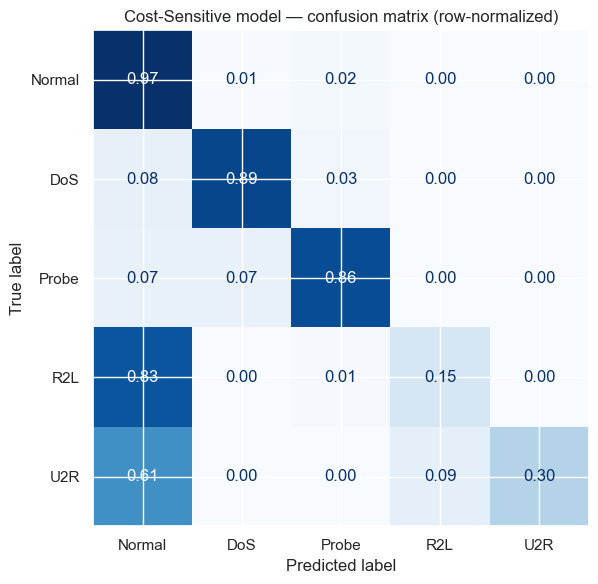

        Normal   DoS  Probe  R2L  U2R
Normal    9428    71    206    2    4
DoS        563  6360    244    0    0
Probe      167   168   2086    0    0
R2L       2406     1     23  445   10
U2R         41     0      0    6   20


In [21]:
# Confusion matrix — cost-sensitive model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = list(id_to_name.values())

cm_norm_cost = confusion_matrix(y_test, y_pred_cost, normalize='true')

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_cost, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=False)
plt.title("Cost-Sensitive model — confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()

cm_raw_cost = confusion_matrix(y_test, y_pred_cost)
print(pd.DataFrame(cm_raw_cost, index=class_names, columns=class_names))

In [22]:
model_125 = XGBClassifier()
model_125.load_model("../models/xgboost_125_final.json")

pred_125 = model_125.predict(X_test_125)
print(f"Loaded baseline (125-feature, balanced weights) macro F1: "
      f"{f1_score(y_test, pred_125, average='macro'):.4f}")

Loaded baseline (125-feature, balanced weights) macro F1: 0.6407


In [23]:
# Cell — CI-backed PERCENTAGE diff, bootstrapped directly (not scaled after the fact)
def bootstrap_f1_pct_diff(y_true, pred_a, pred_b, n_boot=5000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    classes = sorted(np.unique(y_true))
    diffs = {c: [] for c in classes}
    diffs["macro"] = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, pa, pb = y_true[idx], pred_a[idx], pred_b[idx]

        f1_a_macro = f1_score(yt, pa, average="macro", labels=classes, zero_division=0)
        f1_b_macro = f1_score(yt, pb, average="macro", labels=classes, zero_division=0)
        if f1_a_macro > 0:
            diffs["macro"].append((f1_b_macro - f1_a_macro) / f1_a_macro * 100)

        f1_a = f1_score(yt, pa, average=None, labels=classes, zero_division=0)
        f1_b = f1_score(yt, pb, average=None, labels=classes, zero_division=0)
        for c, da, db in zip(classes, f1_a, f1_b):
            if da > 0:
                diffs[c].append((db - da) / da * 100)

    results = {}
    for key, vals in diffs.items():
        vals = np.array(vals)
        lo, hi = np.percentile(vals, [2.5, 97.5])
        results[key] = (vals.mean(), lo, hi)
    return results

results_pct = bootstrap_f1_pct_diff(y_test, pred_125, y_pred_cost)

print(f"{'Class':10s} {'mean %':>10s} {'95% CI':>22s}  verdict")
for key, (mean_pct, lo, hi) in results_pct.items():
    label = "Macro F1" if key == "macro" else id_to_name[key]
    verdict = "real INCREASE" if lo > 0 else "real DECREASE" if hi < 0 else "within noise"
    print(f"{label:10s} {mean_pct:>+9.2f}%  [{lo:+6.2f}%, {hi:+6.2f}%]  {verdict}")

Class          mean %                 95% CI  verdict
Normal         +2.10%  [ +1.82%,  +2.36%]  real INCREASE
DoS            +2.17%  [ +1.88%,  +2.46%]  real INCREASE
Probe          -0.67%  [ -1.19%,  -0.15%]  real DECREASE
R2L           +10.92%  [ +6.89%, +15.30%]  real INCREASE
U2R            +2.65%  [-11.67%, +20.00%]  within noise
Macro F1       +2.07%  [ +0.28%,  +4.03%]  real INCREASE


In [12]:
import os, json
import joblib
import pandas as pd
from sklearn.metrics import f1_score

os.makedirs("../models/custom_weights", exist_ok=True)

BEST_RECORD_PATH = "../models/custom_weights/best_run_record.json"
MODEL_PATH = "../models/custom_weights/xgboost_cost_final.json"
METADATA_PATH = "../models/custom_weights/xgboost_cost_metadata.pkl"

current_macro_f1 = f1_score(y_test, y_pred_cost, average='macro')

if os.path.exists(BEST_RECORD_PATH):
    with open(BEST_RECORD_PATH) as f:
        best_record = json.load(f)
    best_f1 = best_record["macro_f1"]
else:
    best_f1 = -1.0

best_f1_display = best_f1 if best_f1 >= 0 else 0.0

print(f"This run's macro F1: {current_macro_f1:.4f}")
print(f"Best so far:         {best_f1_display:.4f}" if best_f1 >= 0 else "No prior best recorded yet")

if current_macro_f1 > best_f1:
    xgb_cost.save_model(MODEL_PATH)
    joblib.dump({"feature_count": 125, "params": FIXED_PARAMS,
                 "weight_scheme": "balanced + custom (R2L x1.5, U2R x3.0)"}, METADATA_PATH)

    new_record = {
        "macro_f1": current_macro_f1,
        "timestamp": pd.Timestamp.now().isoformat(),
        "model_config": "125-feature hybrid, custom class weights (cost-sensitive)",
    }
    with open(BEST_RECORD_PATH, "w") as f:
        json.dump(new_record, f, indent=2)

    print(f"✅ NEW BEST — saved (macro F1 {current_macro_f1:.4f} > previous best {best_f1_display:.4f})")
else:
    print(f"⏭  Not an improvement — skipping save, existing model file untouched")

This run's macro F1: 0.6418
No prior best recorded yet
✅ NEW BEST — saved (macro F1 0.6418 > previous best 0.0000)


In [26]:
# ===================================================================
# Sweep multiple custom weight configs, evaluate each against the
# loaded 125-feature baseline (pred_125), keep the best one only.
# ===================================================================
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

weight_configs = [
    {"name": "r2l3.0_u2r3.0", "r2l_mult": 3.0, "u2r_mult": 3.0},
    {"name": "r2l3.0_u2r3.5", "r2l_mult": 3.0, "u2r_mult": 3.5},
    {"name": "r2l3.0_u2r4.0", "r2l_mult": 3.0, "u2r_mult": 4.0},
    {"name": "r2l4.0_u2r4.0", "r2l_mult": 4.0, "u2r_mult": 4.0},
]

R2L_ID = 3   # adjust if your label_map differs
U2R_ID = 4

base_weight = compute_sample_weight(class_weight="balanced", y=y_train)

sweep_results = []
best_config = None
best_f1_this_sweep = -1.0
best_model = None
best_pred = None

for cfg in weight_configs:
    custom_weight = base_weight.copy()
    custom_weight[y_train == R2L_ID] *= cfg["r2l_mult"]
    custom_weight[y_train == U2R_ID] *= cfg["u2r_mult"]

    xgb_cost = XGBClassifier(**FIXED_PARAMS)
    xgb_cost.fit(X_train_125, y_train, sample_weight=custom_weight)
    y_pred_cost = xgb_cost.predict(X_test_125)

    macro_f1 = f1_score(y_test, y_pred_cost, average='macro')
    r2l_f1 = f1_score(y_test, y_pred_cost, labels=[R2L_ID], average='macro')
    u2r_f1 = f1_score(y_test, y_pred_cost, labels=[U2R_ID], average='macro')

    sweep_results.append({**cfg, "macro_f1": macro_f1, "r2l_f1": r2l_f1, "u2r_f1": u2r_f1})
    print(f"{cfg['name']:18s} macro={macro_f1:.4f}  R2L={r2l_f1:.4f}  U2R={u2r_f1:.4f}")

    if macro_f1 > best_f1_this_sweep:
        best_f1_this_sweep = macro_f1
        best_config = cfg
        best_model = xgb_cost
        best_pred = y_pred_cost

print(f"\nBest config this sweep: {best_config['name']} (macro F1 {best_f1_this_sweep:.4f})")

r2l3.0_u2r3.0      macro=0.6522  R2L=0.2820  U2R=0.3711
r2l3.0_u2r3.5      macro=0.6461  R2L=0.2917  U2R=0.3469
r2l3.0_u2r4.0      macro=0.6445  R2L=0.2728  U2R=0.3469
r2l4.0_u2r4.0      macro=0.6539  R2L=0.2666  U2R=0.3960

Best config this sweep: r2l4.0_u2r4.0 (macro F1 0.6539)
